# 04. Deep Learning for Demand Forecasting (LSTM)
This notebook explores Long Short-Term Memory (LSTM) networks to capture complex temporal dependencies in NYC taxi demand.

### Key Innovations:
- **3D Data Reshaping**: Transforming tabular data into [Samples, Time-steps, Features].
- **Memory-Efficient Training**: Using `TimeseriesGenerator` to stream data into the GPU/CPU.
- **Advanced Evaluation**: Comparing Deep Learning results with our XGBoost baseline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from google.cloud import bigquery
from dotenv import load_dotenv
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

load_dotenv('../.env')
client = bigquery.Client()

d:\Bon Bon\SourceCode\git\DW-and-DSS-for-Travel-Demand-Predicttion\.venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.1) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## 1. Data Acquisition (BigQuery)
We pull the same unified dataset used in XGBoost to ensure a fair comparison.

In [2]:
project_id = os.getenv("BQ_PROJECT_ID")
dataset_id = os.getenv("BQ_DATASET_ID", "nyc_taxi_dw")

query = f"""
SELECT 
    f.pickup_time_key as Time_Key, 
    f.pulocationid as PULocation_Key, 
    f.total_demand,
    t.hour, t.day_of_week_number
FROM `{project_id}.{dataset_id}.Fact_Demand_Hourly` f
JOIN `{project_id}.{dataset_id}.Dim_Time` t ON f.pickup_time_key = t.Time_Key
WHERE f.service_type_key = 1
ORDER BY PULocation_Key, Time_Key
"""

df = client.query(query).to_dataframe()
# Focus on a specific high-demand zone for LSTM training (e.g., Zone 161)
df_zone = df[df['PULocation_Key'] == 161].copy()
print(f"Data points for Zone 161: {len(df_zone)}")

d:\Bon Bon\SourceCode\git\DW-and-DSS-for-Travel-Demand-Predicttion\.venv\lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Data points for Zone 161: 4368


## 2. Scaling & Pre-processing
LSTMs are sensitive to scale. We use `MinMaxScaler` (0-1) for all features.

In [3]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_zone[['total_demand', 'hour', 'day_of_week_number']])

# Target is the first column (total_demand)
y_data = scaled_data[:, 0]

# Split Index (Time-based)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

## 3. Creating the Timeseries Generator
Instead of creating a massive 3D array in RAM, we use a Generator that provides batches of 24 hours of history to predict the next hour.

In [4]:
n_input = 24 # Look back 24 hours
batch_size = 32

train_generator = TimeseriesGenerator(train_data, train_data[:, 0], 
                                      length=n_input, batch_size=batch_size)

test_generator = TimeseriesGenerator(test_data, test_data[:, 0], 
                                     length=n_input, batch_size=batch_size)

## 4. LSTM Model Architecture
A stacked LSTM with Dropout layers to prevent overfitting.

In [5]:
n_features = train_data.shape[1] # [total_demand, hour, day_of_week]

model = Sequential([
    Input(shape=(n_input, n_features)),
    LSTM(64, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training with Early Stopping

In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(train_generator, 
                    epochs=50, 
                    validation_data=test_generator, 
                    callbacks=[early_stop])

Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0449 - val_loss: 0.0142
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0086 - val_loss: 0.0075
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0066 - val_loss: 0.0066
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0056 - val_loss: 0.0053
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0047 - val_loss: 0.0065
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0049 - val_loss: 0.0051
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0042 - val_loss: 0.0047
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0042 - val_loss: 0.0056
Epoch 9/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0045 - val_loss: 0.0052
Epoch 10/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0042 - val_loss: 0.0064
Epoch 11/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0039 - val_loss: 0.0041
Epoch 12/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 

## 6. Model Persistence
Save the Keras model and the Scaler for future inference.

In [7]:
import joblib

model.save('../saved_models/lstm/lstm_demand_model_v1.keras')
joblib.dump(scaler, '../saved_models/scalers/lstm_scaler.pkl')
print("LSTM Model and Scaler saved successfully!")

LSTM Model and Scaler saved successfully!


## 7. Results Visualization

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


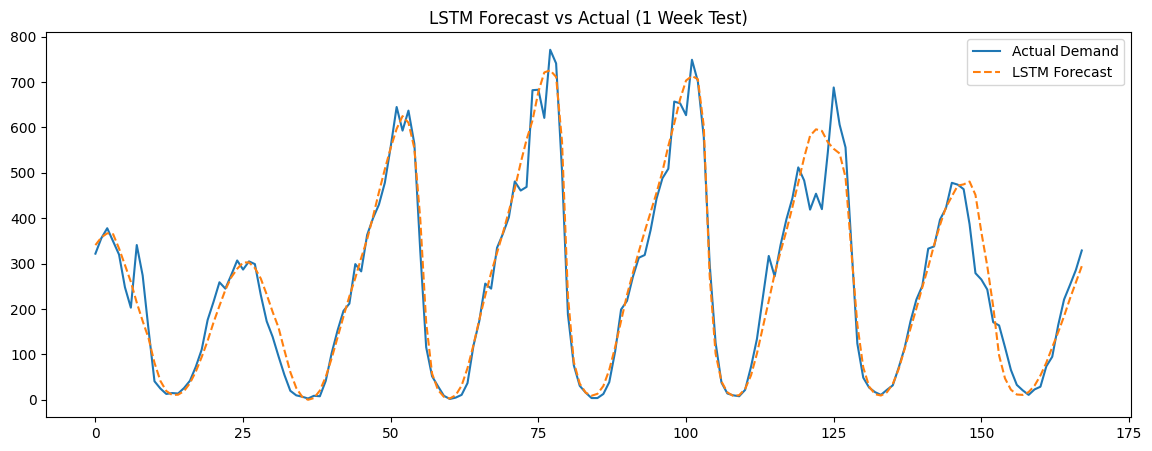

In [8]:
predictions = model.predict(test_generator)

# Inverse transform to get real trip counts
# (Requires dummy columns to match scaler shape)
pred_df = pd.DataFrame(np.zeros((len(predictions), n_features)))
pred_df[0] = predictions
actual_predictions = scaler.inverse_transform(pred_df)[:, 0]

actual_values = df_zone['total_demand'].values[train_size + n_input:]

plt.figure(figsize=(14, 5))
plt.plot(actual_values[:168], label='Actual Demand')
plt.plot(actual_predictions[:168], label='LSTM Forecast', linestyle='--')
plt.title("LSTM Forecast vs Actual (1 Week Test)")
plt.legend()
plt.show()